In [2]:
!pip install pyspark

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import GBTRegressor, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.window import Window

%matplotlib inline
sns.set_style("whitegrid")

## Ініціалізація Spark

In [4]:
spark = SparkSession.builder \
    .appName("US Accidents Kaggle") \
    .master("local[*]") \
    .config("spark.driver.memory", "12g") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/30 20:22:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 3.5.1


## Load df

In [5]:
dataset_path = "/kaggle/input/us-accidents/US_Accidents_March23.csv"

print("Завантаження даних...")
df = spark.read.csv(dataset_path, header=True, inferSchema=True)

print(f"Всього рядків: {df.count()}")
df.printSchema()

Завантаження даних...


Всього рядків: 7728394
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- End_Time: string (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable 

## Feature Engineering

In [6]:
print("--- Агрегація даних v3 (All States Scale) ---")

df_clean = df.withColumn("Date", F.to_date("Start_Time")) \
             .filter(F.col("State").isNotNull()) # На всяк випадок

df_daily = df_clean.groupBy("State", "Date") \
                   .agg(F.count("*").alias("Daily_Accidents")) \
                   .orderBy("Date")

df_features = df_daily.withColumn("DayOfWeek", F.dayofweek("Date")) \
                      .withColumn("DayOfMonth", F.dayofmonth("Date")) \
                      .withColumn("Month", F.month("Date")) \
                      .withColumn("Year", F.year("Date")) \
                      .withColumn("Is_Weekend", F.when(F.dayofweek("Date").isin([1, 7]), 1).otherwise(0))

w = Window.partitionBy("State").orderBy("Date")

df_features = df_features.withColumn("Accidents_Yesterday", F.lag("Daily_Accidents", 1).over(w))

df_features = df_features.withColumn("Accidents_Last_Week", F.lag("Daily_Accidents", 7).over(w))

w_rolling = Window.partitionBy("State").orderBy("Date").rowsBetween(-7, -1)
df_features = df_features.withColumn("Rolling_Avg_7", F.avg("Daily_Accidents").over(w_rolling))

df_final_clean = df_features.dropna()

count = df_final_clean.count()
print(f"Дані підготовлено (Всі штати). Кількість рядків: {count}")

stages = []

indexer = StringIndexer(inputCol="State", outputCol="State_Index")
encoder = OneHotEncoder(inputCols=["State_Index"], outputCols=["State_Vec"])
stages += [indexer, encoder]

input_cols = [
    "State_Vec",
    "DayOfWeek", "DayOfMonth", "Month", "Year", "Is_Weekend", 
    "Accidents_Yesterday", "Accidents_Last_Week", "Rolling_Avg_7"
]

assembler = VectorAssembler(inputCols=input_cols, outputCol="raw_features")
stages += [assembler]

scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
stages += [scaler]

pipeline = Pipeline(stages=stages)
model = pipeline.fit(df_final_clean)
final_df = model.transform(df_final_clean)

df = final_df.select(
    F.col("Date"),
    F.col("State"),
    F.col("features"),
    F.col("Daily_Accidents").alias("label")
)

--- Агрегація даних v3 (All States Scale) ---


Дані підготовлено (Всі штати). Кількість рядків: 101108


## Prediction

In [7]:
print("--- MODEL TRAINING (With Gradient Boosting) ---")

train_data, test_data = df.sample(fraction=0.2, seed=42).randomSplit([0.8, 0.2], seed=42)
train_data.cache() 

print(f"Train size: {train_data.count()}")
print(f"Test size:  {test_data.count()}")

evaluator_mae = RegressionEvaluator(metricName="mae")
evaluator_r2 = RegressionEvaluator(metricName="r2")
results = []

# 1. GBT Regressor
print("Training GBT Regressor (Gradient Boosting)...")
gbt = GBTRegressor(featuresCol="features", labelCol="label", maxIter=20, maxDepth=8, seed=42)
gbt_model = gbt.fit(train_data)
res_gbt = gbt_model.transform(test_data)
results.append(("GBT Regressor", evaluator_mae.evaluate(res_gbt), evaluator_r2.evaluate(res_gbt)))
print("GBT Done.")

# 2. Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label", maxDepth=8, seed=42)
dt_model = dt.fit(train_data)
res_dt = dt_model.transform(test_data)
results.append(("Decision Tree", evaluator_mae.evaluate(res_dt), evaluator_r2.evaluate(res_dt)))
print("DT Done.")

# 3. Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=30, maxDepth=8, seed=42)
rf_model = rf.fit(train_data)
res_rf = rf_model.transform(test_data)
results.append(("Random Forest", evaluator_mae.evaluate(res_rf), evaluator_r2.evaluate(res_rf)))
print("RF Done.")

results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"])
display(results_df)

--- MODEL TRAINING (With Gradient Boosting) ---


Train size: 16092


Test size:  4019
Training GBT Regressor (Gradient Boosting)...


GBT Done.
Training Decision Tree...


DT Done.
Training Random Forest...


25/11/30 20:32:21 WARN DAGScheduler: Broadcasting large task binary with size 1124.6 KiB


RF Done.


,Model,MAE,R2
0,GBT Regressor,21.225006,0.838525
1,Decision Tree,23.484688,0.786485
2,Random Forest,21.974728,0.846602


## Visualise

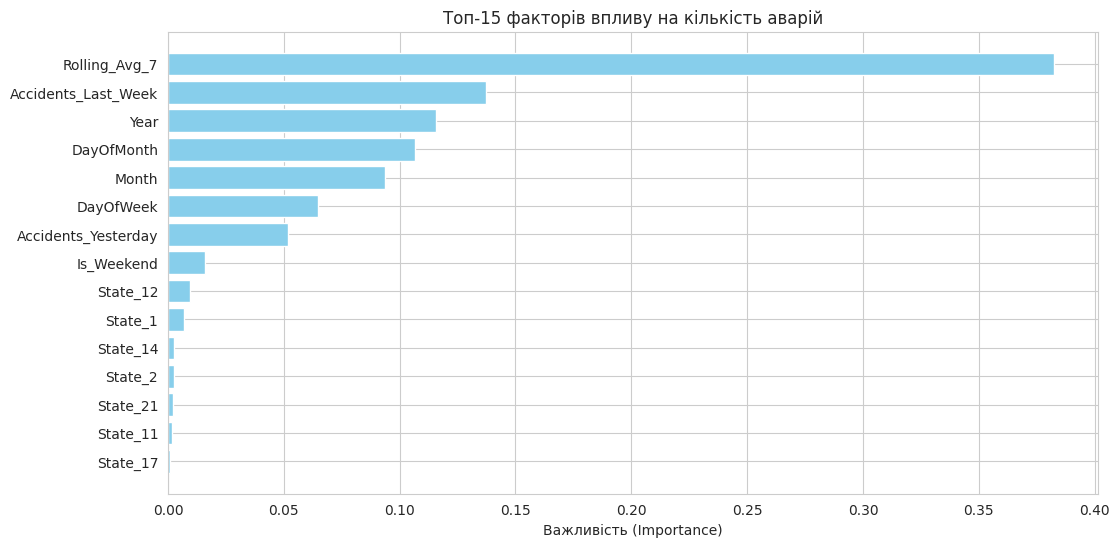

Висновок: Якщо Rolling_Avg_7 або Accidents_Last_Week зверху - модель працює правильно!
Будуємо графік прогнозу для штату: CA


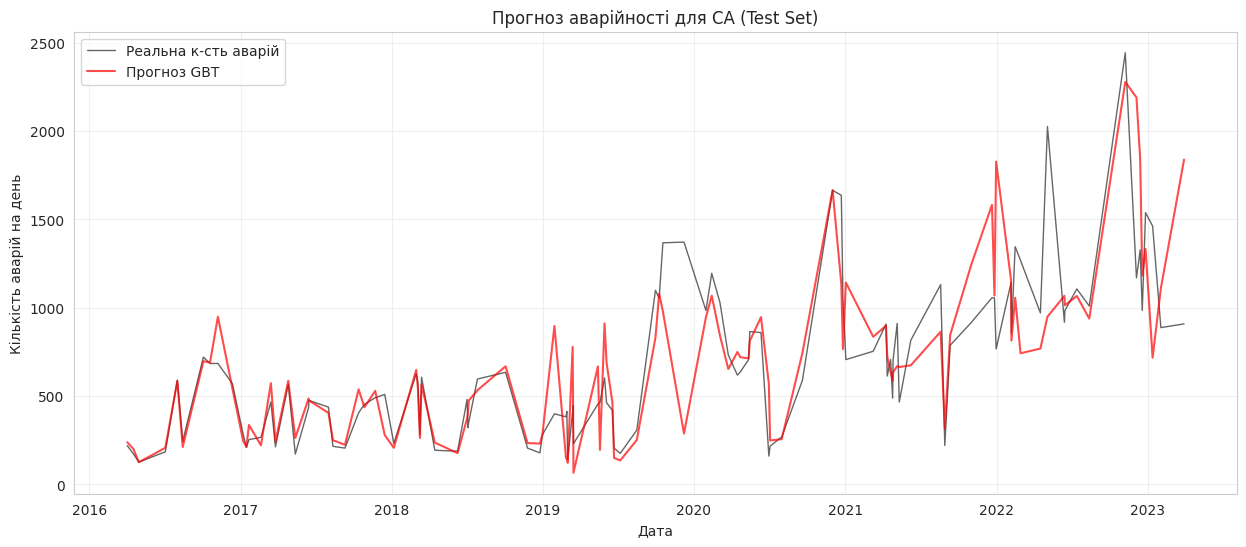

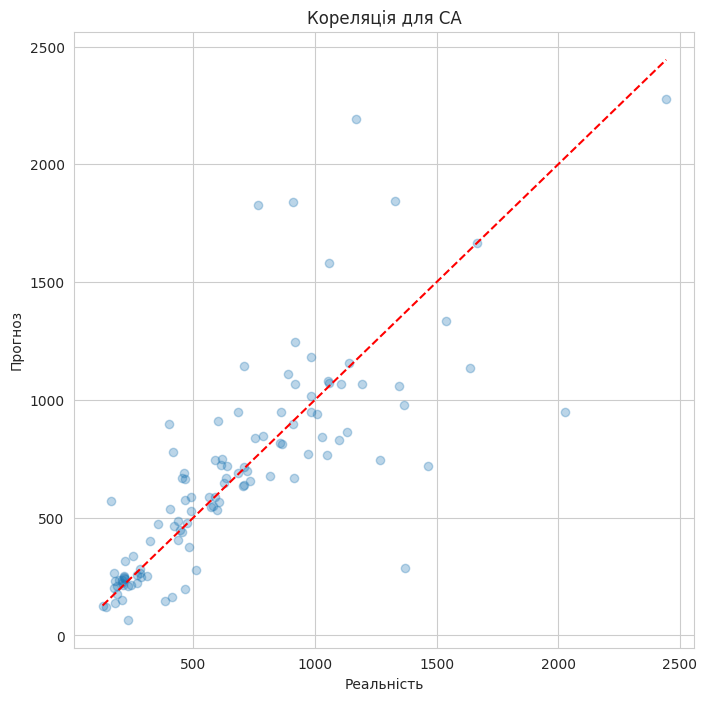

In [8]:
# -------------------------------------------------------
# 1. Feature Importance
# -------------------------------------------------------

model = gbt_model # Або rf_model
importances = model.featureImportances.toArray()

num_numeric_features = 8 # DayOfWeek, DayOfMonth, Month, Year, Is_Weekend, Lag1, Lag7, Rolling
num_state_features = len(importances) - num_numeric_features

feature_names = [f"State_{i}" for i in range(num_state_features)] + [
    "DayOfWeek", "DayOfMonth", "Month", "Year", "Is_Weekend", 
    "Accidents_Yesterday", "Accidents_Last_Week", "Rolling_Avg_7"
]

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
top_15 = feat_imp_df.head(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='skyblue')
plt.gca().invert_yaxis() # Щоб найважливіші були зверху
plt.title("Топ-15 факторів впливу на кількість аварій")
plt.xlabel("Важливість (Importance)")
plt.show()

print("Висновок: Якщо Rolling_Avg_7 або Accidents_Last_Week зверху - модель працює правильно!")

target_state = "CA"

# -------------------------------------------------------
# 2. ПРОГНОЗ VS РЕАЛЬНІСТЬ
# -------------------------------------------------------

print(f"Будуємо графік прогнозу для штату: {target_state}")

df_viz = res_gbt.filter(F.col("State") == target_state) \
                .select("Date", "label", "prediction") \
                .orderBy("Date")

pdf_viz = df_viz.toPandas()

pdf_viz['Date'] = pd.to_datetime(pdf_viz['Date'])

plt.figure(figsize=(15, 6))

plt.plot(pdf_viz['Date'], pdf_viz['label'], label='Реальна к-сть аварій', color='black', alpha=0.6, linewidth=1)

plt.plot(pdf_viz['Date'], pdf_viz['prediction'], label='Прогноз GBT', color='red', alpha=0.7, linewidth=1.5)

plt.title(f"Прогноз аварійності для {target_state} (Test Set)")
plt.xlabel("Дата")
plt.ylabel("Кількість аварій на день")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(pdf_viz['label'], pdf_viz['prediction'], alpha=0.3)
plt.plot([pdf_viz['label'].min(), pdf_viz['label'].max()], 
         [pdf_viz['label'].min(), pdf_viz['label'].max()], 'r--') # Ідеальна лінія
plt.xlabel("Реальність")
plt.ylabel("Прогноз")
plt.title(f"Кореляція для {target_state}")
plt.show()